In [4]:
import pandas as pd

In [9]:
# Get data
medical_df = pd.read_csv("datasets/insurance.csv")

print(medical_df.head())
print(medical_df.shape)

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
(1338, 7)


In [10]:
# Check for null values
print(medical_df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [11]:
# Convert categorical variables to dummy variables
medical_df = pd.get_dummies(medical_df, drop_first=True)

print(medical_df.head())

   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [12]:
X = medical_df.drop("charges", axis=1).values
y = medical_df["charges"].values

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Shapes of the training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1070, 8)
X_test shape: (268, 8)
y_train shape: (1070,)
y_test shape: (268,)


### Baseline Models

In [13]:
# Imports 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt

In [17]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=1.0)
}

pipelines = {
    name: Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)])
        for name, model in models.items()
}

In [18]:
results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, pipeline in pipelines.items():
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=kf)
    results[name] = cv_scores
    print(f"{name}: Mean R^2: {cv_scores.mean():.4f}, Std: {cv_scores.std():.4f}")

Linear Regression: Mean R^2: 0.7389, Std: 0.0311
Ridge Regression: Mean R^2: 0.7389, Std: 0.0311
Lasso Regression: Mean R^2: 0.7389, Std: 0.0310


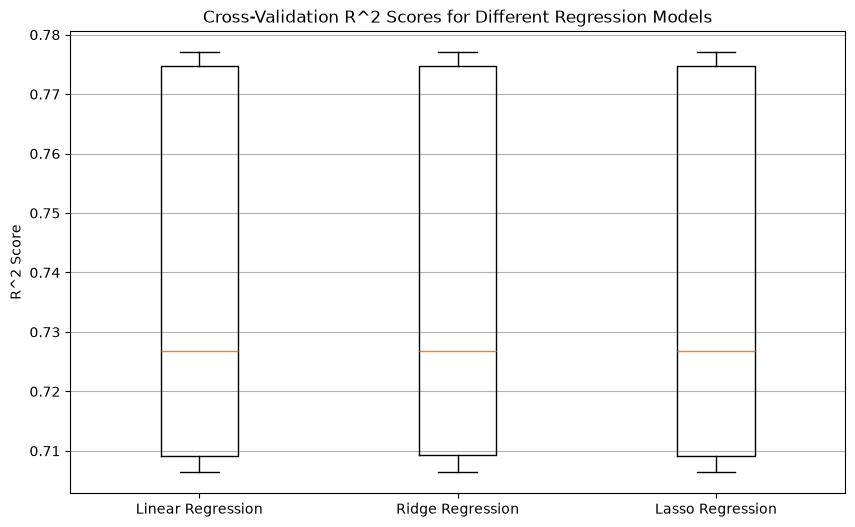

In [19]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.boxplot(results.values(), label=pipelines.keys())
plt.title("Cross-Validation R^2 Scores for Different Regression Models")
plt.xticks(range(1, len(results) + 1), results.keys())
plt.ylabel("R^2 Score")
plt.grid(axis='y')
plt.show()

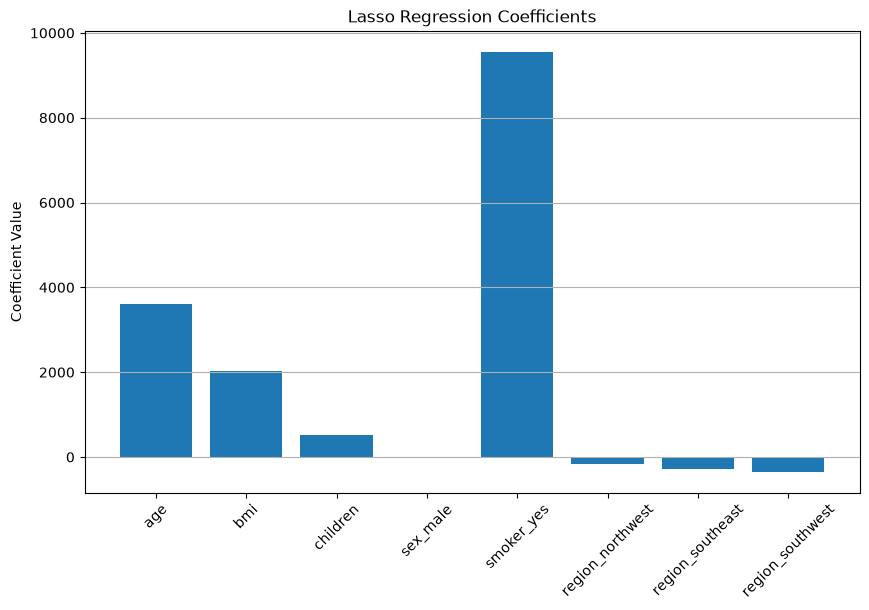

In [20]:
# Check lasso coefficients
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)

lasso_coefficients = lasso.coef_
feature_names = medical_df.drop("charges", axis=1).columns

# Visualize the coefficients
plt.figure(figsize=(10, 6))
plt.bar(feature_names, lasso_coefficients)
plt.title("Lasso Regression Coefficients")
plt.xticks(rotation=45)
plt.ylabel("Coefficient Value")
plt.grid(axis='y')
plt.show()

In [27]:
# Tune lasso alpha using cross-validation
import numpy as np
from sklearn.model_selection import GridSearchCV

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso())
])

param_grid = {
    "lasso__alpha": np.linspace(0.00001, 1.0, 100)
}

tuning = GridSearchCV(lasso_pipeline, param_grid, cv=kf)

print("Tuning Lasso Regression...")
tuning.fit(X_train, y_train)

print("Best alpha:", tuning.best_params_["lasso__alpha"])
print("Best cross-validation score:", tuning.best_score_)

Tuning Lasso Regression...
Best alpha: 1.0
Best cross-validation score: 0.7388577650275883


In [29]:
# Check the final model's performance on the test set
from sklearn.metrics import r2_score, root_mean_squared_error

best_model = tuning.best_estimator_
y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Test R^2: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test R^2: 0.7836
Test RMSE: 5796.6496


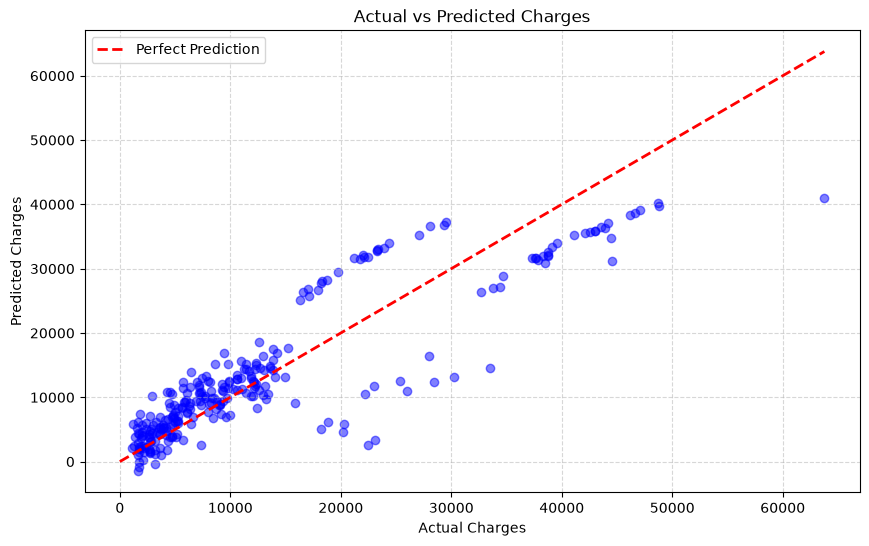

In [30]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color ='blue')

max_val = max(max(y_test), max(y_pred))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.title("Actual vs Predicted Charges")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.legend()
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.show()

### 📊 Model Evaluation & Key Insights: Medical Cost Regression

**Overall Performance**
The optimized Lasso Regression model demonstrated a balanced baseline performance on the test dataset. Following hyperparameter tuning (`alpha=1.0`), the model successfully explained approximately **78% ($R^2$: 0.78)** of the variance in medical charges.

**Cost Drivers & Feature Selection (Lasso)**
Lasso's regularization mechanism effectively filtered out the actual drivers inflating the medical bills, making the model highly interpretable:
* 🚬 **Smoking Status:** Proved to be the most dominant factor increasing the charges by a wide margin.
* 📈 **Age and BMI:** Measured as the other two strong and consistent drivers pushing the charges upward.
* ✂️ **Irrelevant Noise:** Gender (`sex_male`) and geographical regions were proven to have no statistical weight on the charges; Lasso completely zeroed out their coefficients, eliminating them from the equation.

**Visual Insights & Model Limitations**
The Actual vs. Predicted scatter plot clearly outlines the model's behavior and the absolute limitations of linear algorithms:
* **High Accuracy on Low Charges:** For actual charges under $15,000, the blue prediction points closely follow the red dashed line, representing near-perfect predictions.
* **Detachment and Banding:** As actual charges exceed $15,000, the blue points significantly detach from the ideal red line, forming distinct parallel bands above and below it.

> **💡 Data Science Context:** 
> *This parallel banding in the scatter plot represents the bulk errors inherently made by linear models. A linear model simply adds factors together. However, in the real world, when "Smoking" and "High BMI (Obesity)" combine, the health risks compound exponentially rather than additively. Because Lasso cannot capture these non-linear cross-interactions, its predictions fail for high-risk patients. To push the performance beyond 85%, the next logical step is transitioning to tree-based models (like Random Forest or Gradient Boosting) that can branch out and capture these complex conditions.*